In [35]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (13, 13)
fruits = pd.read_table('fruits.txt')
fruits.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [2]:
# basic analysis. No weird stuff
fruits.shape

(59, 7)

In [3]:
fruits['fruit_name'].unique()

array(['apple', 'mandarin', 'orange', 'lemon'], dtype=object)

In [4]:
fruits.groupby('fruit_name').size()

fruit_name
apple       19
lemon       16
mandarin     5
orange      19
dtype: int64

In [5]:
counts = _

In [6]:
counts

fruit_name
apple       19
lemon       16
mandarin     5
orange      19
dtype: int64

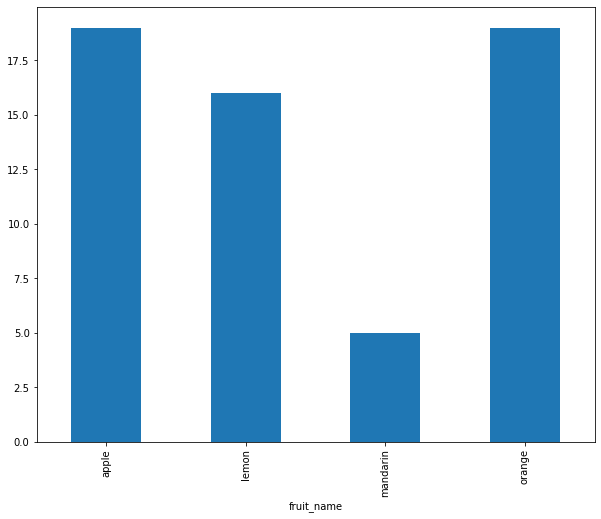

In [9]:
# basic analysis
counts.plot(kind='bar')

In [13]:
fruits.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


##  `fruit_label` is out target. So, remove it!
We are concentrating on continuous features (`mass`, `width`, `heigth`, `color_score`), looking for possible relationship between the features, thus a possible predictable behaviour.

In [15]:
label_removed = fruits.drop('fruit_label', axis=1)

In [16]:
label_removed.head()

,fruit_name,fruit_subtype,mass,width,height,color_score
0,apple,granny_smith,192,8.4,7.3,0.55
1,apple,granny_smith,180,8.0,6.8,0.59
2,apple,granny_smith,176,7.4,7.2,0.60
3,mandarin,mandarin,86,6.2,4.7,0.80
4,mandarin,mandarin,84,6.0,4.6,0.79


mass              AxesSubplot(0.125,0.536818;0.352273x0.343182)
width          AxesSubplot(0.547727,0.536818;0.352273x0.343182)
height               AxesSubplot(0.125,0.125;0.352273x0.343182)
color_score       AxesSubplot(0.547727,0.125;0.352273x0.343182)
dtype: object

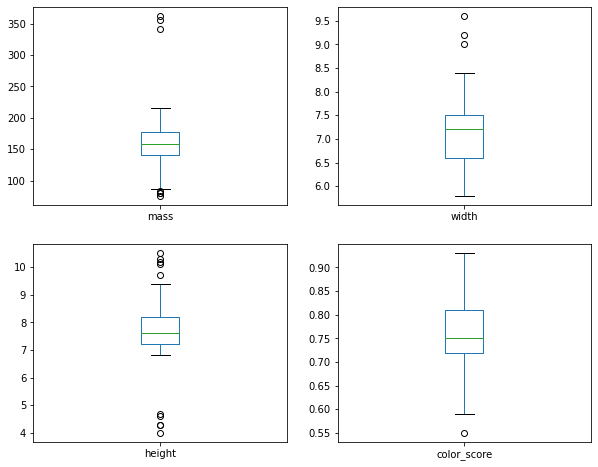

In [17]:
label_removed.plot(kind='box', subplots=True, layout=(2,2))

## `color_score` looks like gaussian (almost).

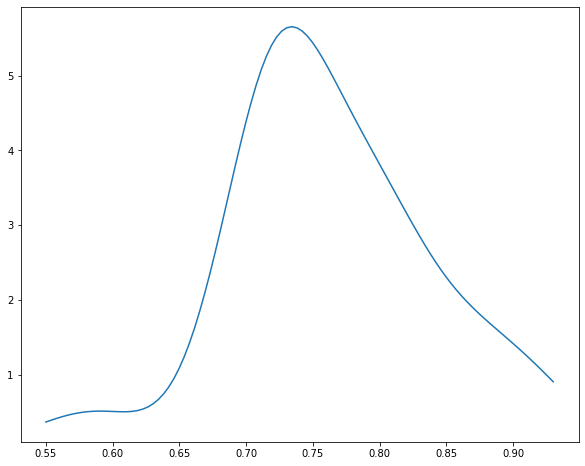

In [88]:
from scipy.stats import gaussian_kde
import numpy as np

kde = gaussian_kde(label_removed['color_score'])
space = np.linspace(min(label_removed['color_score']), max(label_removed['color_score']), 100)
plt.plot(space, kde(space))

### Let's see in details all the distributions

We are looking for correlations between the continuous variables.

In [18]:
label_removed.head()

,fruit_name,fruit_subtype,mass,width,height,color_score
0,apple,granny_smith,192,8.4,7.3,0.55
1,apple,granny_smith,180,8.0,6.8,0.59
2,apple,granny_smith,176,7.4,7.2,0.60
3,mandarin,mandarin,86,6.2,4.7,0.80
4,mandarin,mandarin,84,6.0,4.6,0.79


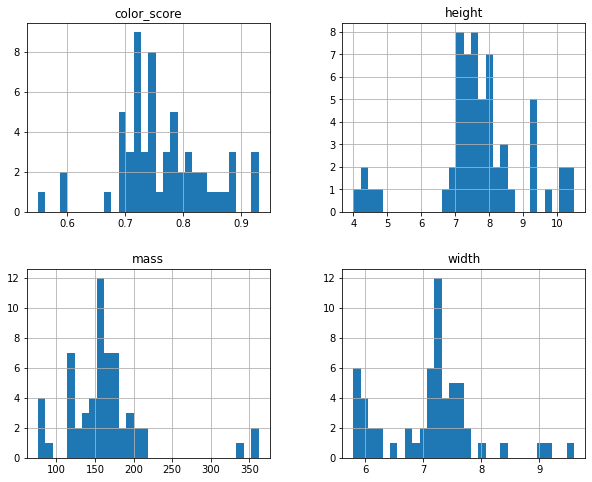

In [24]:
label_removed.hist(bins=30)
plt.savefig('fruits')
plt.show()

In [25]:
from matplotlib import cm

In [26]:
feature_names = ['mass', 'width', 'height', 'color_score']

In [27]:
X = fruits[feature_names]

In [28]:
type(X)

pandas.core.frame.DataFrame

In [29]:
X.head()

,mass,width,height,color_score
0,192,8.4,7.3,0.55
1,180,8.0,6.8,0.59
2,176,7.4,7.2,0.60
3,86,6.2,4.7,0.80
4,84,6.0,4.6,0.79


In [30]:
y = fruits['fruit_label']

In [32]:
y.head()

0    1
1    1
2    1
3    2
4    2
Name: fruit_label, dtype: int64

In [33]:
cmap = cm.get_cmap('gnuplot')

The scatter matrix is a powerful tool to visually identify relations between variables.

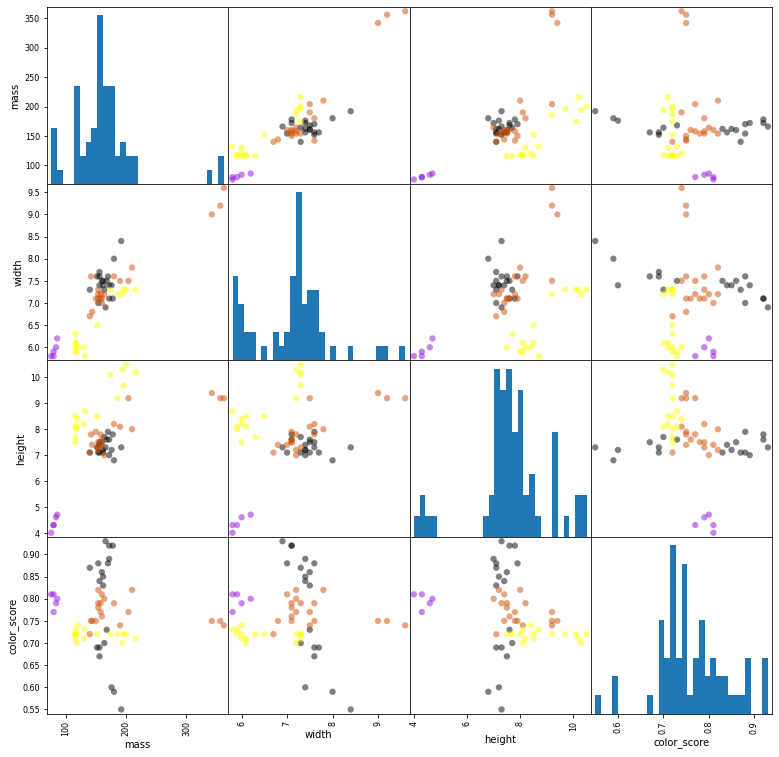

In [36]:
scatter = pd.plotting.scatter_matrix(X, c=y, marker='o', s=40, hist_kwds={'bins':30}, cmap=cmap)
plt.savefig('fruits_scatter')
plt.show()

Strong correlation between `mass` and `width`. (straightforward, don't you think??: the larger a fruit, the heavier. Sounds intuitive!).

`color_score` completely unrelated with other features.

In [37]:
X.head()

,mass,width,height,color_score
0,192,8.4,7.3,0.55
1,180,8.0,6.8,0.59
2,176,7.4,7.2,0.60
3,86,6.2,4.7,0.80
4,84,6.0,4.6,0.79


### TRAINING and TESTING

To split the dataset into training and testing sets we use the `sklearn` method.

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [42]:
X_train.shape  # 75-25 training/testing

(44, 4)

In [43]:
X_test.shape

(15, 4)

In [45]:
15 / 59

0.2542372881355932

It's important to scale the numeric values of continuous features to the same scale. **The range of all features should be normalized so that each feature contributes approximately proportionately to the final result.**

In [46]:
from sklearn.preprocessing import MinMaxScaler

In [47]:
X_train.head()

,mass,width,height,color_score
42,154,7.2,7.2,0.82
48,174,7.3,10.1,0.72
7,76,5.8,4.0,0.81
14,152,7.6,7.3,0.69
32,164,7.2,7.0,0.80


In [48]:
scaler = MinMaxScaler()

In [49]:
X_train = scaler.fit_transform(X_train)

We fit the data on the training set and then we transform them accordingly. **WE LEARN THE RESPECTIVE CONTRIBUTIONS OF EACH FEATURE**

In [51]:
X_test = scaler.transform(X_test)

We transform **ONLY** the testing set, accordingly. **WE DO NOT LEARN FROM THE TESTING SET**

In [89]:
# Same information as `X` but scaled and in numpy.ndarray (no more pd.DataFrame)
X_train[5:]

array([[0.2       , 0.        , 0.72307692, 0.48648649],
       [0.3       , 0.35294118, 0.52307692, 0.7027027 ],
       [0.27857143, 0.44117647, 0.50769231, 0.64864865],
       [0.14285714, 0.02941176, 0.63076923, 0.48648649],
       [0.30714286, 0.5       , 0.47692308, 0.75675676],
       [0.14285714, 0.14705882, 0.56923077, 0.45945946],
       [0.45714286, 0.5       , 0.8       , 0.59459459],
       [0.28571429, 0.55882353, 0.47692308, 0.37837838],
       [0.01428571, 0.        , 0.04615385, 0.59459459],
       [0.47857143, 0.58823529, 0.61538462, 0.72972973],
       [0.28571429, 0.52941176, 0.53846154, 0.32432432],
       [0.19285714, 0.05882353, 0.64615385, 0.43243243],
       [0.3       , 0.5       , 0.53846154, 0.83783784],
       [0.14285714, 0.05882353, 0.53846154, 0.45945946],
       [0.36428571, 0.38235294, 0.58461538, 1.        ],
       [0.31428571, 0.44117647, 0.56923077, 0.40540541],
       [1.        , 1.        , 0.8       , 0.54054054],
       [0.32857143, 0.5       ,

## IT'S MODEL TIME!!!

In [91]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
print(f'training {logreg.score(X_train, y_train)}')
print(f'testing {logreg.score(X_test, y_test)}')

training 0.75
testing 0.4666666666666667


In [92]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier().fit(X_train, y_train)
print(f'training {dt.score(X_train, y_train)}')
print(f'testing {dt.score(X_test, y_test)}')

training 1.0
testing 0.6666666666666666


In [93]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier().fit(X_train, y_train)
print(f'training {knn.score(X_train, y_train)}')
print(f'testing {knn.score(X_test, y_test)}')

training 0.9545454545454546
testing 1.0


In [94]:
from sklearn.svm import SVC
svc = SVC().fit(X_train, y_train)
print(f'training {svc.score(X_train, y_train)}')
print(f'testing {svc.score(X_test, y_test)}')

training 0.9090909090909091
testing 0.8


## FINAL STANDING

Score on testing set
- Winner : knn
- 2nd: svm
- 3rd: dt
- 4th: logreg

In [72]:
from sklearn.metrics import classification_report, confusion_matrix

In [73]:
knn.score(X_test, y_test)

1.0

Given the best performance let's try to predict on the testing set.

In [74]:
pred = knn.predict(X_test)

In [90]:
# True positive / False positive
confusion_matrix(y_test, pred)

array([[4, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 8, 0],
       [0, 0, 0, 2]])

In [77]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         2

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



This is **never** happening in real life. This testing set is to small. Anyway, we have the perfect classifier!! 


### How to choose K?
Iterate multiple time, and chose the highest score.

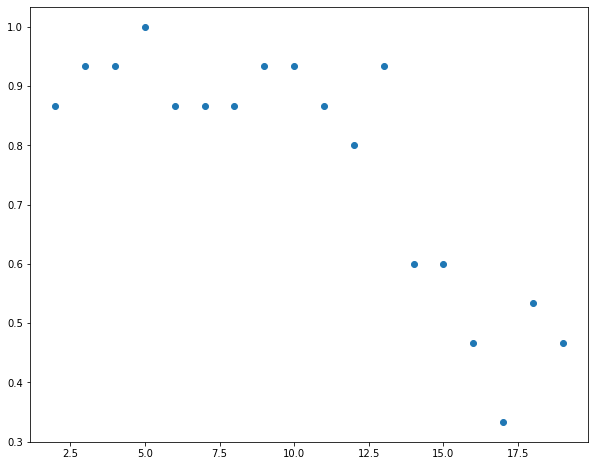

In [79]:
plt.rcParams['figure.figsize'] = (10, 8)
k_range = range(2,20)

scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))
    
plt.scatter(k_range, scores)